In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
# to ensure consistency
data = pd.read_csv("./preprocessed_data.csv", low_memory = False)

In [4]:
data.drop(columns = ['encounter_id', 'patient_nbr'], axis = 1, inplace = True)

In [5]:
data = data.fillna("None")

In [6]:
data.shape

(70431, 28)

In [7]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

ohe_cols = ["diag_1", "diag_2", "diag_3"]

ordinal_cols = [
    "race", "gender", "max_glu_serum", "A1Cresult", "insulin",
    "change", "diabetesMed", "metformin", "glimepiride",
    "glipizide", "glyburide", "pioglitazone", "rosiglitazone", "age"
]

ordinal_categories = [
    ["Caucasian", "AfricanAmerican", "Hispanic", "Asian", "Other", "None"],
    ["Male", "Female", "None"],
    ["None", "Norm", ">200", ">300"],
    ["None", "Norm", ">7", ">8"],
    ["No", "Steady", "Change", "None"],
    ["No", "Ch", "None"],
    ["No", "Yes", "None"],
    ["No", "Steady", "Change", "None"],
    ["No", "Steady", "Change", "None"],
    ["No", "Steady", "Change", "None"],
    ["No", "Steady", "Change", "None"],
    ["No", "Steady", "Change", "None"],
    ["No", "Steady", "Change", "None"],
    ["[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
     "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)", "None"],
]

ohe = OneHotEncoder(drop=None, handle_unknown="ignore", sparse_output=False)
data_ohe = pd.DataFrame(
    ohe.fit_transform(data[ohe_cols]),
    columns=ohe.get_feature_names_out(ohe_cols),
    index=data.index
)

ordinal = OrdinalEncoder(categories=ordinal_categories, handle_unknown="use_encoded_value", unknown_value=-1)
data_ord = pd.DataFrame(
    ordinal.fit_transform(data[ordinal_cols]),
    columns=ordinal_cols,
    index=data.index
)

data_remaining = data.drop(columns=ohe_cols + ordinal_cols)

data_encoded = pd.concat([data_remaining, data_ohe, data_ord], axis=1)

In [8]:
pd.set_option("display.max_columns", None)

In [9]:
X = data_encoded.drop(columns=["readmitted"])
y = data_encoded['readmitted']

### Training

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [11]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight = 'balanced', max_samples = 0.8)

param_grid = {
    'n_estimators': [100, 200],        # number of trees
    'max_depth': [None, 5, 10, 15],        # tree depth
    'min_samples_split': [5, 10],        # min samples to split a node
    'min_samples_leaf': [2, 5, 10],          # min samples per leaf
    'max_features': [0.3, 'sqrt']        # feature subset for splitting
}

In [12]:
from sklearn.metrics import make_scorer, f1_score, roc_auc_score
# scoring = make_scorer(f1_score, pos_label=1)
scoring = make_scorer(roc_auc_score, needs_proba=True)

In [13]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),              
    n_jobs=-1,          
    verbose=2,          
    scoring=scoring         
)

In [14]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 96 candidates, totalling 288 fits


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(class_weight='balanced',
                                              max_samples=0.8, n_jobs=-1,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15],
                         'max_features': [0.3, 'sqrt'],
                         'min_samples_leaf': [2, 5, 10],
                         'min_samples_split': [5, 10],
                         'n_estimators': [100, 200]},
             scoring=make_scorer(roc_auc_score, response_method='predict_proba'),
             verbose=2)

In [15]:
print("Best parameters found:", grid_search.best_params_)
print("Best cross-val score:", grid_search.best_score_)

Best parameters found: {'max_depth': 10, 'max_features': 0.3, 'min_samples_leaf': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-val score: 0.6453170881725695


In [16]:
best_rf = grid_search.best_estimator_

In [17]:
y_pred = best_rf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.7152863227638429

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.74      0.83     19242
           1       0.14      0.44      0.22      1888

    accuracy                           0.72     21130
   macro avg       0.54      0.59      0.52     21130
weighted avg       0.86      0.72      0.77     21130


Confusion Matrix:
 [[14285  4957]
 [ 1059   829]]


In [18]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(accuracy)
print(precision)
print(recall)
print(f1)

0.7152863227638429
0.8605999845561617
0.715286322763843
0.7715520597494264


In [19]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Probabilities for the positive class
y_pred_proba = best_rf.predict_proba(X_train)[:, 1]

# Compute AUC
auc_score = roc_auc_score(y_train, y_pred_proba)
print("Train AUC-ROC:", auc_score)

Train AUC-ROC: 0.7728678558310673


In [20]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Probabilities for the positive class
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]

# Compute AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
print("Test AUC-ROC:", auc_score)

Test AUC-ROC: 0.6425919191158465


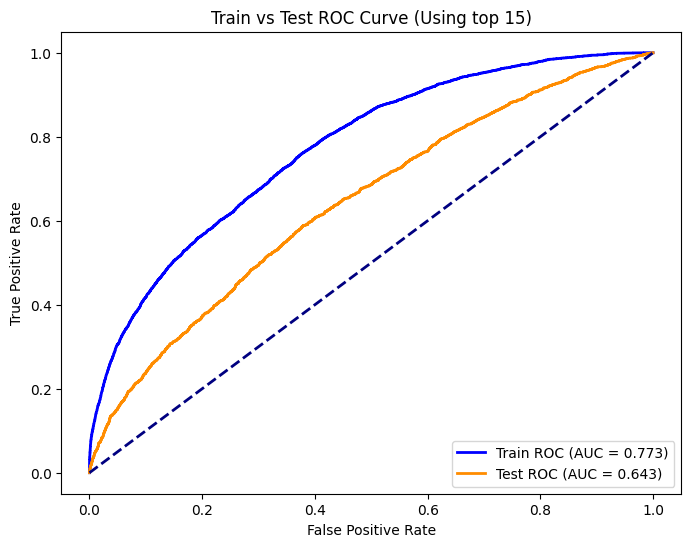

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_pred_proba_train = best_rf.predict_proba(X_train)[:, 1]
y_pred_proba_test = best_rf.predict_proba(X_test)[:, 1]

fpr_train, tpr_train, _ = roc_curve(y_train, y_pred_proba_train)
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_proba_test)

auc_train = roc_auc_score(y_train, y_pred_proba_train)
auc_test = roc_auc_score(y_test, y_pred_proba_test)

plt.figure(figsize=(8,6))
plt.plot(fpr_train, tpr_train, color='blue', lw=2,
         label=f'Train ROC (AUC = {auc_train:.3f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2,
         label=f'Test ROC (AUC = {auc_test:.3f})')

# Diagonal reference line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Train vs Test ROC Curve (Using top 15)')
plt.legend(loc='lower right')
plt.show()

In [22]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)         # not so good because based on gini impurtiy
print(importances.sort_values(ascending=False).head(15))

discharge_disposition_id                     0.202799
num_lab_procedures                           0.094551
number_inpatient                             0.087312
num_medications                              0.072788
time_in_hospital                             0.059542
age                                          0.050861
number_diagnoses                             0.046772
num_procedures                               0.029957
admission_type_id                            0.021822
number_emergency                             0.019116
diag_1_Diseases of the circulatory system    0.018856
insulin                                      0.017029
race                                         0.016881
number_outpatient                            0.013546
A1Cresult                                    0.013509
dtype: float64


### Re-fit based on just top 15 variables from the training set 

In [23]:
top_15 = importances.sort_values(ascending=False).head(15).reset_index()['index']

In [24]:
X = X[top_15]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [26]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 96 candidates, totalling 288 fits


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(class_weight='balanced',
                                              max_samples=0.8, n_jobs=-1,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15],
                         'max_features': [0.3, 'sqrt'],
                         'min_samples_leaf': [2, 5, 10],
                         'min_samples_split': [5, 10],
                         'n_estimators': [100, 200]},
             scoring=make_scorer(roc_auc_score, response_method='predict_proba'),
             verbose=2)

In [27]:
print("Best parameters found:", grid_search.best_params_)
print("Best cross-val score:", grid_search.best_score_)

Best parameters found: {'max_depth': 5, 'max_features': 0.3, 'min_samples_leaf': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-val score: 0.6377690407958652


In [28]:
best_rf = grid_search.best_estimator_

In [29]:
y_pred = best_rf.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.61      0.74     19242
           1       0.13      0.59      0.21      1888

    accuracy                           0.60     21130
   macro avg       0.53      0.60      0.47     21130
weighted avg       0.86      0.60      0.69     21130


Confusion Matrix:
 [[11651  7591]
 [  779  1109]]


In [30]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall    = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1        = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("Model Performance Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Model Performance Metrics:
Accuracy : 0.6039
Precision: 0.8650
Recall   : 0.6039
F1-Score : 0.6887


In [31]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Probabilities for the positive class
y_pred_proba = best_rf.predict_proba(X_train)[:, 1]

# Compute AUC
auc_score = roc_auc_score(y_train, y_pred_proba)
print("Train AUC-ROC:", auc_score)

Train AUC-ROC: 0.6568601021566403


In [32]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Probabilities for the positive class
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]

# Compute AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
print("Test AUC-ROC:", auc_score)

Test AUC-ROC: 0.6372441375592586


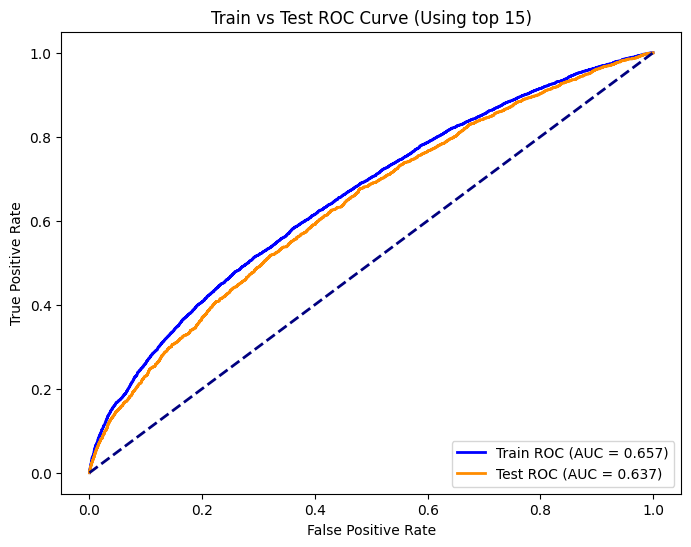

In [33]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_pred_proba_train = best_rf.predict_proba(X_train)[:, 1]
y_pred_proba_test = best_rf.predict_proba(X_test)[:, 1]

fpr_train, tpr_train, _ = roc_curve(y_train, y_pred_proba_train)
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_proba_test)

auc_train = roc_auc_score(y_train, y_pred_proba_train)
auc_test = roc_auc_score(y_test, y_pred_proba_test)

plt.figure(figsize=(8,6))
plt.plot(fpr_train, tpr_train, color='blue', lw=2,
         label=f'Train ROC (AUC = {auc_train:.3f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2,
         label=f'Test ROC (AUC = {auc_test:.3f})')

# Diagonal reference line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Train vs Test ROC Curve (Using top 15)')
plt.legend(loc='lower right')
plt.show()

### Try using Balanced RF (experimentation)

In [ ]:
X = data_encoded.drop(columns=["readmitted"])
y = data_encoded['readmitted']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, make_scorer

brf = BalancedRandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt']
}

scoring = make_scorer(f1_score, pos_label=1)

grid_search = GridSearchCV(
    estimator=brf,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=2,
    scoring=scoring
)

grid_search.fit(X_train, y_train)
best_brf = grid_search.best_estimator_

print("Best Params:", grid_search.best_params_)


In [ ]:
print("Best parameters found:", grid_search.best_params_)
print("Best cross-val score:", grid_search.best_score_)

In [ ]:
best_rf = grid_search.best_estimator_

In [ ]:
y_pred = best_rf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [ ]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(accuracy)
print(precision)
print(recall)
print(f1)

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Probabilities for the positive class
y_pred_proba = best_rf.predict_proba(X_train)[:, 1]

# Compute AUC
auc_score = roc_auc_score(y_train, y_pred_proba)
print("Train AUC-ROC:", auc_score)

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Probabilities for the positive class
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]

# Compute AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
print("Test AUC-ROC:", auc_score)

In [ ]:
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

### Re-fit based on just top 15 variables from the training set 

In [ ]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)         # not so good because based on gini impurtiy
print(importances.sort_values(ascending=False).head(15))

In [ ]:
top_15 = importances.sort_values(ascending=False).head(15).reset_index()['index']

In [ ]:
importances.sort_values(ascending=False).head(15).reset_index().rename(columns = {0: 'Feature Importance'})

In [ ]:
X = X[top_15]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
grid_search.fit(X_train, y_train)

In [ ]:
print("Best parameters found:", grid_search.best_params_)
print("Best cross-val score:", grid_search.best_score_)

In [ ]:
best_rf = grid_search.best_estimator_

In [ ]:
y_pred = best_rf.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [ ]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall    = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1        = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("Model Performance Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Probabilities for the positive class
y_pred_proba = best_rf.predict_proba(X_train)[:, 1]

# Compute AUC
auc_score = roc_auc_score(y_train, y_pred_proba)
print("Train AUC-ROC:", auc_score)

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Probabilities for the positive class
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]

# Compute AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
print("Test AUC-ROC:", auc_score)

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_pred_proba_train = best_rf.predict_proba(X_train)[:, 1]
y_pred_proba_test = best_rf.predict_proba(X_test)[:, 1]

fpr_train, tpr_train, _ = roc_curve(y_train, y_pred_proba_train)
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_proba_test)

auc_train = roc_auc_score(y_train, y_pred_proba_train)
auc_test = roc_auc_score(y_test, y_pred_proba_test)

plt.figure(figsize=(8,6))
plt.plot(fpr_train, tpr_train, color='blue', lw=2,
         label=f'Train ROC (AUC = {auc_train:.3f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2,
         label=f'Test ROC (AUC = {auc_test:.3f})')

# Diagonal reference line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Train vs Test ROC Curve (Using top 15)')
plt.legend(loc='lower right')
plt.show()